# Phase 3  — Fine-tuning `ChurnRisk`

 entraîner un modèle qui prédit `ChurnRisk` (Faible / Moyen / Élevé)




 modèle entraîné ** sur les contacts au sentiment Négatif** (`SentimentLabel == "Négatif"`)




In [1]:
!pip install -q transformers datasets evaluate accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

import evaluate
import torch
import random
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Configuration

In [3]:
CONFIG = {
    "DATA_PATH": r"data_prete_labeled.csv",
    "TEXT_COL": "clean_text_v2",
    "LANG_COL": "langue",
    "LABEL_COL": "ChurnRisk",

    "MODEL_NAME": "xlm-roberta-base",
    "MAX_LENGTH": 128,
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,
    "SEED": 42,

    "OUTPUT_DIR": "./churnrisk_xlmr_negatif",
    "BATCH_SIZE": 16,
    "NUM_EPOCHS": 6,
    "LEARNING_RATE": 2e-5,
}


## 1 — Chargement des données

In [4]:
from google.colab import files
uploaded = files.upload()  # sélectionne data_prete_labeled.csv
CONFIG["DATA_PATH"] = list(uploaded.keys())[0]


Saving data_prete_labeled.csv to data_prete_labeled.csv


In [5]:
df = pd.read_csv(CONFIG["DATA_PATH"])
print("Shape :", df.shape)

assert CONFIG["LABEL_COL"] in df.columns, f"{CONFIG['LABEL_COL']} absent — as-tu bien uploadé data_prete_labeled.csv (sortie de la Phase 1) ?"
assert CONFIG["TEXT_COL"] in df.columns, f"{CONFIG['TEXT_COL']} absent du corpus."

df = df.dropna(subset=[CONFIG["LABEL_COL"], CONFIG["TEXT_COL"]]).reset_index(drop=True)
print("Shape après nettoyage :", df.shape)

df[CONFIG["LABEL_COL"]].value_counts()


Shape : (4740, 40)
Shape après nettoyage : (4740, 40)


,count
ChurnRisk,
Moyen,2379
Élevé,1624
Faible,737


### Filtrage : sentiment négatif uniquement


In [6]:
assert "SentimentLabel" in df.columns, "SentimentLabel absent — nécessaire pour filtrer sur le sentiment négatif."

n_avant = len(df)
df = df[df["SentimentLabel"] == "Négatif"].reset_index(drop=True)
print(f"Lignes conservées (SentimentLabel == 'Négatif') : {len(df)} / {n_avant} ({100*len(df)/n_avant:.1f}%)")

print("\nDistribution ChurnRisk sur ce sous-ensemble :")
print(df[CONFIG["LABEL_COL"]].value_counts())

# Avec un sous-ensemble plus petit, certaines classes ChurnRisk peuvent devenir très rares —
# à surveiller avant de lancer le split 3 voies (train/val/test a besoin d'assez d'exemples
# par classe pour stratifier correctement).
effectifs_label = df[CONFIG["LABEL_COL"]].value_counts()
classes_fragiles = effectifs_label[effectifs_label < 30]
if len(classes_fragiles) > 0:
    print("\n Classe(s) ChurnRisk avec moins de 30 exemples après filtrage — le split train/val/test")
    print("   et l'entraînement seront peu fiables sur cette/ces classe(s) :")
    print(classes_fragiles)


Lignes conservées (SentimentLabel == 'Négatif') : 1328 / 4740 (28.0%)

Distribution ChurnRisk sur ce sous-ensemble :
ChurnRisk
Élevé    1188
Moyen     140
Name: count, dtype: int64


## 2 — Vérification du biais langue × ChurnRisk

Même contrôle que pour `SentimentLabel` : on vérifie que le modèle ne pourra pas se contenter d'utiliser la langue comme raccourci pour prédire le risque de churn.

In [7]:
crosstab = pd.crosstab(df[CONFIG["LANG_COL"]], df[CONFIG["LABEL_COL"]])
print(crosstab)

crosstab_pct = pd.crosstab(df[CONFIG["LANG_COL"]], df[CONFIG["LABEL_COL"]], normalize="index") * 100
print("\nEn % par langue :")
print(crosstab_pct.round(1))

if (crosstab == 0).any().any():
    print("\n Au moins une combinaison langue x ChurnRisk est totalement absente — biais potentiel, à documenter.")
else:
    print("\nToutes les combinaisons langue x ChurnRisk sont représentées.")


ChurnRisk  Moyen  Élevé
langue                 
arabe         70    514
arabizi       22    178
français      48    496

En % par langue :
ChurnRisk  Moyen  Élevé
langue                 
arabe       12.0   88.0
arabizi     11.0   89.0
français     8.8   91.2

Toutes les combinaisons langue x ChurnRisk sont représentées.


## 3 — Encodage des labels et split stratifié train / val / test (par template)

Le split est fait au niveau du **template** (`template_id`) : toutes les lignes issues d'un même template restent ensemble dans un seul sous-ensemble (train, val ou test)

In [ ]:
assert "template_id" in df.columns, "template_id absent — vérifie que tu utilises bien data_prete_labeled.csv (sortie Phase 1)."

labels_uniques = sorted(df[CONFIG["LABEL_COL"]].unique())
label2id = {label: i for i, label in enumerate(labels_uniques)}
id2label = {i: label for label, i in label2id.items()}
print("label2id :", label2id)

df["label"] = df[CONFIG["LABEL_COL"]].map(label2id)

# --- Regroupement au niveau du TEMPLATE (pas de la ligne) pour éviter la fuite de données ---
# On résume chaque template par sa langue et son label dominants
template_info = (
    df.groupby("template_id")
      .agg({CONFIG["LANG_COL"]: "first", CONFIG["LABEL_COL"]: "first"})
      .reset_index()
)
template_info["strate"] = (
    template_info[CONFIG["LANG_COL"]].astype(str) + "__" + template_info[CONFIG["LABEL_COL"]].astype(str)
)

def fusionner_strates_rares(info_df, seuil=2):
    """Fusionne les strates avec moins de `seuil` templates pour éviter les erreurs de stratification."""
    effectifs = info_df["strate"].value_counts()
    rares = effectifs[effectifs < seuil].index
    if len(rares) > 0:
        print(f" {len(rares)} strate(s) < {seuil} templates, fusionnées :", list(rares))
        info_df.loc[info_df["strate"].isin(rares), "strate"] = "autre__autre"
    return info_df

template_info = fusionner_strates_rares(template_info)

# Rappel : après filtrage sur SentimentLabel == "Négatif", certaines classes ChurnRisk
# sont potentiellement rares (voir avertissement "classes fragiles" plus haut) — le
# regroupement par template est encore plus important ici, sur un sous-ensemble réduit.


In [ ]:
# Split des TEMPLATES (pas des lignes) — 70/15/15
train_tpl, temp_tpl = train_test_split(
    template_info,
    test_size=(1 - CONFIG["TRAIN_FRAC"]),
    stratify=template_info["strate"],
    random_state=CONFIG["SEED"],
)

# Sécurité : on refusionne les strates devenues trop petites AVANT le 2e split
# (une strate à 3 templates peut tomber à 1 seul dans temp_tpl après le 1er split,
# ce qui ferait planter le split stratifié suivant)
temp_tpl = fusionner_strates_rares(temp_tpl.copy())

val_ratio_of_temp = CONFIG["VAL_FRAC"] / (CONFIG["VAL_FRAC"] + CONFIG["TEST_FRAC"])
val_tpl, test_tpl = train_test_split(
    temp_tpl,
    test_size=(1 - val_ratio_of_temp),
    stratify=temp_tpl["strate"],
    random_state=CONFIG["SEED"],
)

# On applique le split de templates aux LIGNES du corpus
train_df = df[df["template_id"].isin(train_tpl["template_id"])].reset_index(drop=True)
val_df   = df[df["template_id"].isin(val_tpl["template_id"])].reset_index(drop=True)
test_df  = df[df["template_id"].isin(test_tpl["template_id"])].reset_index(drop=True)

print(f"Train : {len(train_df)} lignes ({train_df['template_id'].nunique()} templates)")
print(f"Val   : {len(val_df)} lignes ({val_df['template_id'].nunique()} templates)")
print(f"Test  : {len(test_df)} lignes ({test_df['template_id'].nunique()} templates)")

for nom, sous_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n--- {nom} — répartition {CONFIG['LABEL_COL']} ---")
    print(sous_df[CONFIG["LABEL_COL"]].value_counts(normalize=True).round(3))


## 4 — Vérification GPU

In [10]:
print("CUDA disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Aucun GPU détecté — Exécution > Modifier le type d'exécution > GPU (T4 gratuit).")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CUDA disponible : True
GPU : Tesla T4


## 5 — Tokenisation

In [11]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])

def to_hf_dataset(sous_df):
    return Dataset.from_pandas(
        sous_df[[CONFIG["TEXT_COL"], "label"]].rename(columns={CONFIG["TEXT_COL"]: "text"}),
        preserve_index=False,
    )

raw_datasets = DatasetDict({
    "train": to_hf_dataset(train_df),
    "validation": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
})

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=CONFIG["MAX_LENGTH"],
    )

tokenized_datasets = raw_datasets.map(tokenize_fn, batched=True)
tokenized_datasets


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/929 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 929
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 199
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 200
    })
})

## 6 — Modèle et métriques

In [ ]:
counts = Counter(train_df["label"])
n_total = sum(counts.values())
n_classes = len(label2id)

# Sécurité : une classe absente du train set ferait planter le calcul des poids (division par zéro)
# — risque réel ici vu les classes ChurnRisk parfois très petites après filtrage sur sentiment négatif
for i in range(n_classes):
    if counts[i] == 0:
        raise ValueError(f"La classe '{id2label[i]}' n'a aucun exemple dans train_df — le split pose problème.")

class_weights = torch.tensor(
    [n_total / (n_classes * counts[i]) for i in range(n_classes)],
    dtype=torch.float,
).to(device)
print("Poids par classe :", {id2label[i]: round(w.item(), 3) for i, w in enumerate(class_weights)})

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["MODEL_NAME"],
    num_labels=n_classes,
    id2label=id2label,
    label2id=label2id,
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1_macro": f1, "precision_macro": precision, "recall_macro": recall}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


## 7 — Entraînement

In [13]:
import torch

print("CUDA disponible :", torch.cuda.is_available())
print("Nombre de GPU :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA disponible : True
Nombre de GPU : 1
GPU : Tesla T4


In [14]:
training_args = TrainingArguments(
    output_dir=CONFIG["OUTPUT_DIR"],
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=CONFIG["LEARNING_RATE"],
    per_device_train_batch_size=CONFIG["BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["BATCH_SIZE"],
    num_train_epochs=CONFIG["NUM_EPOCHS"],
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=CONFIG["SEED"],
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.667693,0.350107,0.894472,0.796712,0.746855,0.920011
2,0.498062,0.330510,0.909548,0.812970,0.765331,0.907437
3,0.331869,0.804159,0.899497,0.763095,0.738910,0.796816
4,0.382718,0.671265,0.899497,0.778791,0.743184,0.838818


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=236, training_loss=0.45500209776021666, metrics={'train_runtime': 343.935, 'train_samples_per_second': 16.207, 'train_steps_per_second': 1.029, 'total_flos': 244430170429440.0, 'train_loss': 0.45500209776021666, 'epoch': 4.0})

## 8 — Évaluation sur le test set



Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.382718,0.248552,4,0.895000,0.796895,0.746875,0.920325


{'eval_loss': 0.24855177104473114, 'eval_accuracy': 0.895, 'eval_f1_macro': 0.7968954011315827, 'eval_precision_macro': 0.746875, 'eval_recall_macro': 0.9203245544027667}



               precision    recall  f1-score   support

       Moyen       0.50      0.95      0.66        21
       Élevé       0.99      0.89      0.94       179

    accuracy                           0.90       200
   macro avg       0.75      0.92      0.80       200
weighted avg       0.94      0.90      0.91       200



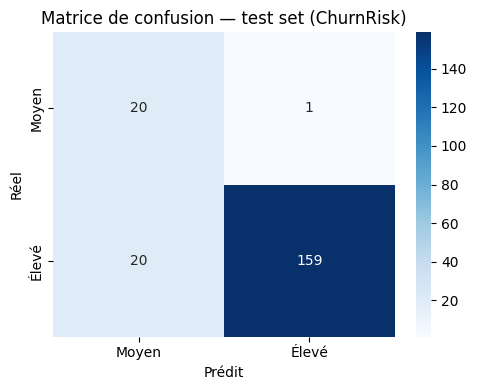

In [15]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

predictions = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print("\n", classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(n_classes)]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(n_classes)],
            yticklabels=[id2label[i] for i in range(n_classes)])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion — test set (ChurnRisk)")
plt.tight_layout()
plt.show()


## 9 — Analyse par langue

In [16]:
test_df_eval = test_df.copy().reset_index(drop=True)
test_df_eval["y_true"] = y_true
test_df_eval["y_pred"] = y_pred

for langue in test_df_eval[CONFIG["LANG_COL"]].unique():
    sous = test_df_eval[test_df_eval[CONFIG["LANG_COL"]] == langue]
    acc = accuracy_score(sous["y_true"], sous["y_pred"])
    print(f"{langue:10s} — n={len(sous):4d} — accuracy={acc:.3f}")


arabizi    — n=  30 — accuracy=0.933
arabe      — n=  88 — accuracy=0.898
français   — n=  82 — accuracy=0.878


## 10 — Sauvegarde du modèle (sur Drive)

Fichier volumineux (~1 Go pour XLM-R-base) — on passe directement par Drive plutôt que par `files.download()`

In [17]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
trainer.save_model(CONFIG["OUTPUT_DIR"])
tokenizer.save_pretrained(CONFIG["OUTPUT_DIR"])

import shutil
shutil.make_archive("churnrisk_xlmr_negatif_model", "zip", CONFIG["OUTPUT_DIR"])

shutil.copy("churnrisk_xlmr_negatif_model.zip", "/content/drive/MyDrive/churnrisk_xlmr_negatif_model.zip")
print("Copié sur Drive : /content/drive/MyDrive/churnrisk_xlmr_negatif_model.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Copié sur Drive : /content/drive/MyDrive/churnrisk_xlmr_negatif_model.zip
